[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/anderson-perez/IAC/blob/main/Aprendizado%20Profundo/Fundamentos_DL.ipynb)

# Inteligência Artificial e Computacional

## Segunda Parte da Disciplina

# Informações:

- Prof. Anderson Luiz Fernandes Perez
- Contato: anderson.perez@ufsc.br | anderson.lfp@gmail.com
- Os materiais da disciplina estarão disponíveis no github (https://github.com/anderson-perez/IAC.git)

## Aprendizado Profundo (Fundamentos)

O Aprendizado Profundo (Deep Learning) é uma subárea do Machine Learning baseada em redes neurais artificiais com muitas camadas.

O elemento principal do aprendizado profundo é o neurônio artificial.

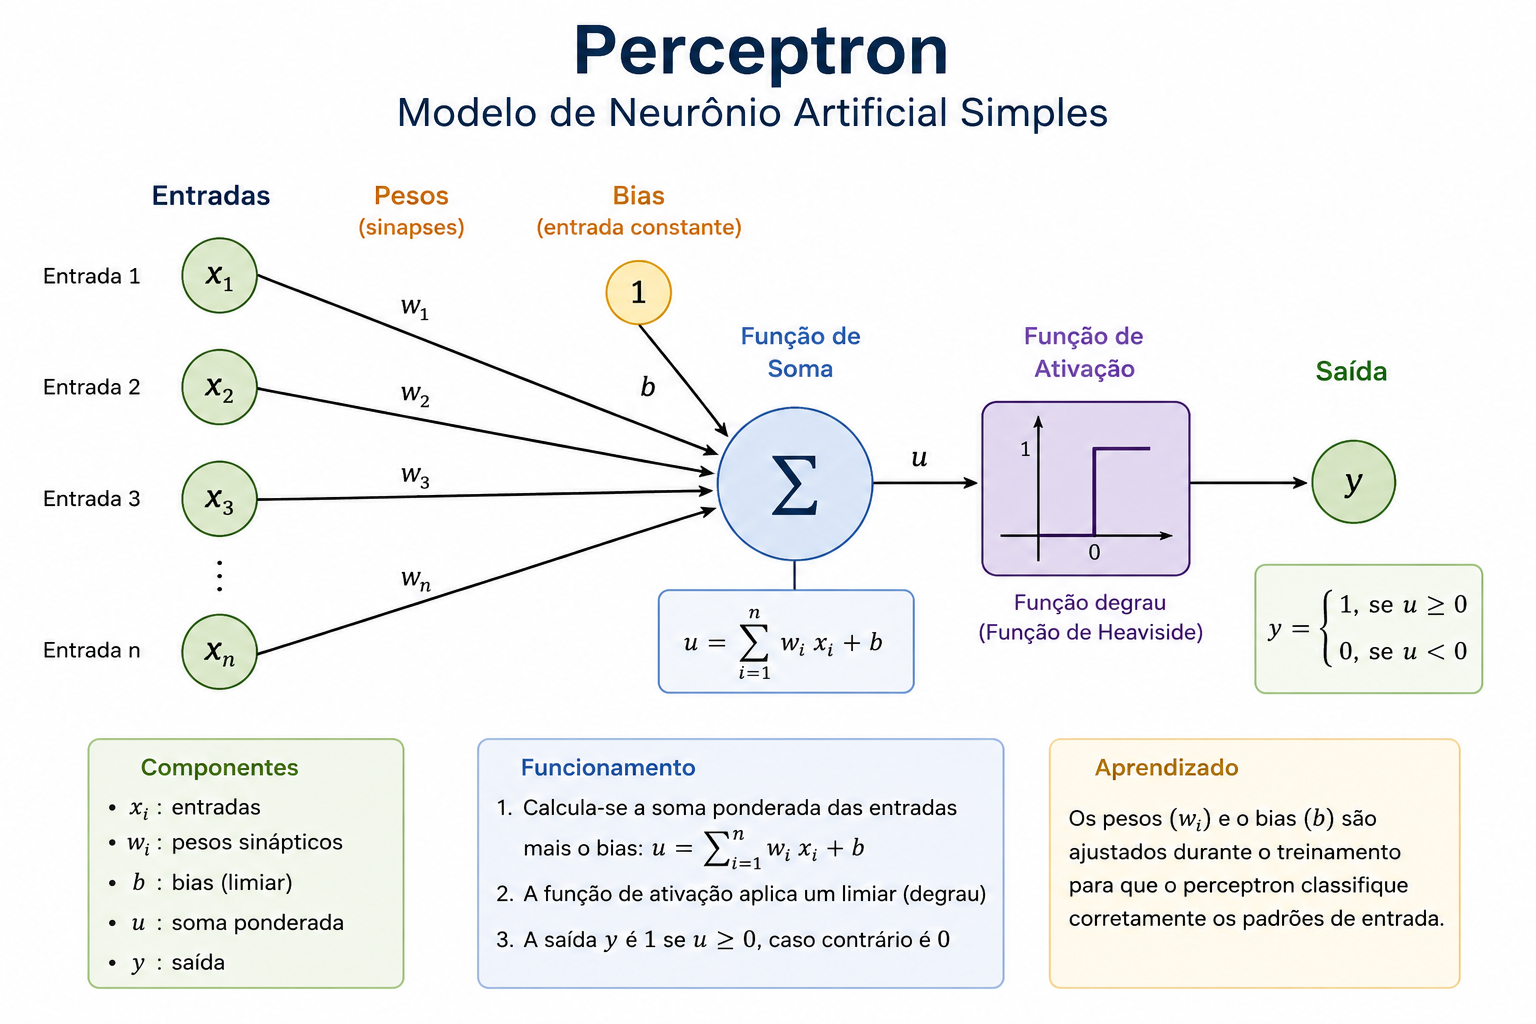

## Processamento de um Neurônio Artificial

- Entradas: $x_1, x_2, ..., x_n$
- Pesos: $w_1, w_2, ..., w_n$
- Bias: $b$
- Função de ativação: $f$
- Saída: $y$

A combinação linear é dada por:

$$
z = \sum_{i=1}^{n} w_i x_i + b
$$

A saída do neurônio é:

$$
y = f(z)
$$

## Redes Neurais Multicamadas (MLP)

Uma **MLP (Multilayer Perceptron)** é uma rede neural composta por:

- Camada de entrada;
- Uma ou mais camadas ocultas;
- Camada de saída.

Cada camada transforma os dados recebidos da camada anterior. Em redes profundas, várias camadas são **empilhadas**, permitindo que a rede aprenda representações cada vez mais abstratas.

Exemplo:

```text
Entrada → Camada Oculta 1 → Camada Oculta 2 → Saída
```

A profundidade da rede está associada ao número de camadas ocultas.

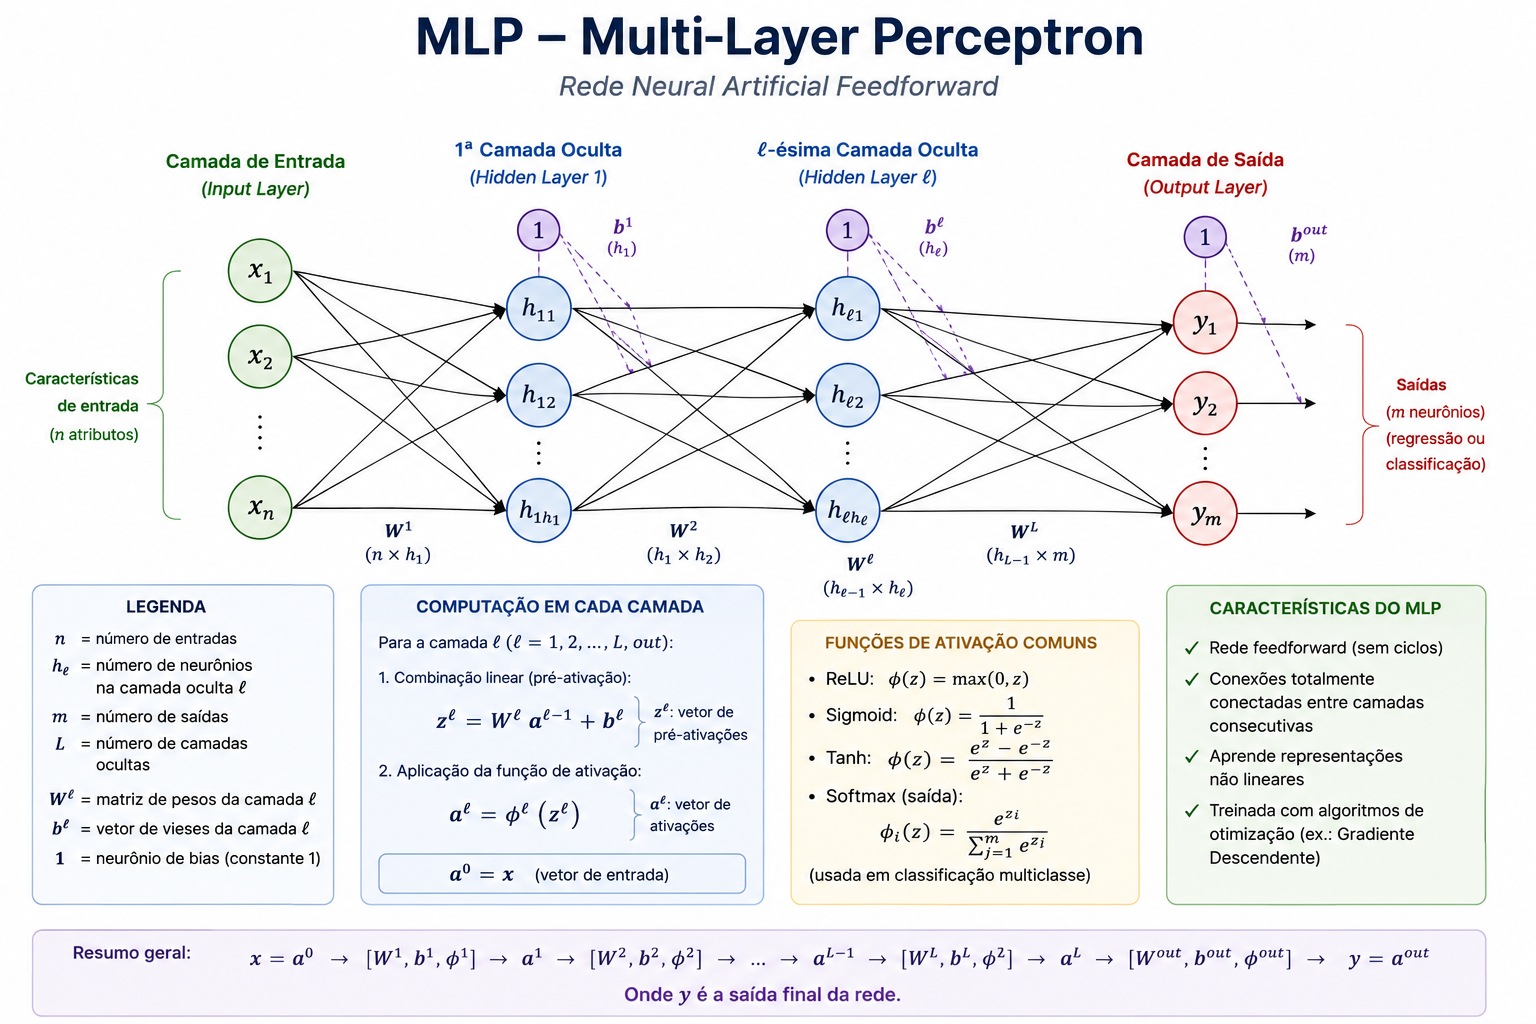

## Funções de ativação

As funções de ativação introduzem **não linearidade** na rede.

Sem funções de ativação não lineares, mesmo uma rede com várias camadas seria equivalente a uma única transformação linear.

Algumas funções comuns são:

- Sigmoid;
- Tanh;
- ReLU;
- Leaky ReLU;
- Softmax.

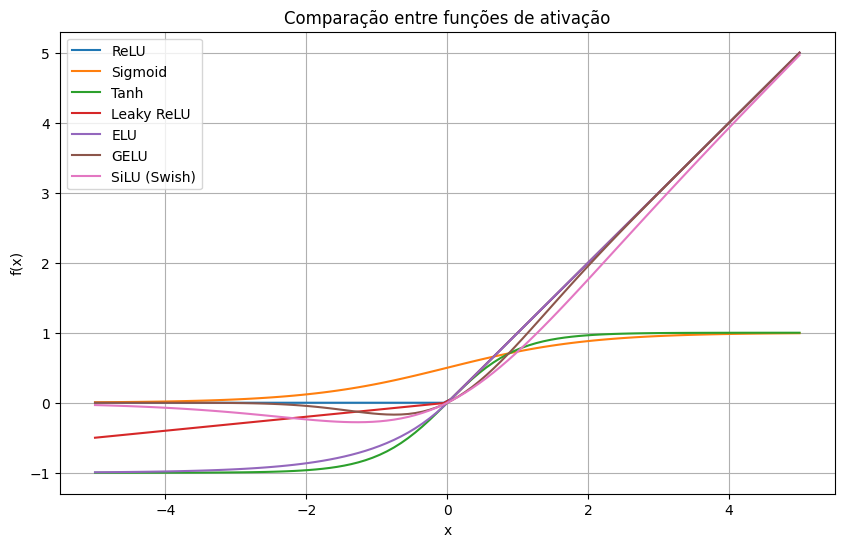

In [33]:
### Exemplo Funções de Ativação
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

x = torch.linspace(-5, 5, 100)

plt.figure(figsize=(10, 6))

plt.plot(x, F.relu(x), label='ReLU')
plt.plot(x, torch.sigmoid(x), label='Sigmoid')
plt.plot(x, torch.tanh(x), label='Tanh')

# Novas funções
plt.plot(x, F.leaky_relu(x, negative_slope=0.1),
         label='Leaky ReLU')

plt.plot(x, F.elu(x),
         label='ELU')

plt.plot(x, F.gelu(x),
         label='GELU')

plt.plot(x, F.silu(x),
         label='SiLU (Swish)')

plt.grid(True)
plt.legend()
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Comparação entre funções de ativação")

plt.show()

## Funções de perda

A função de perda mede o erro entre a saída prevista pela rede e o valor real.

Durante o treinamento, o objetivo é minimizar essa função.

### Regressão: Erro Quadrático Médio

$$
MSE = \frac{1}{N}\sum_{i=1}^{N}(y_i - \hat{y}_i)^2
$$



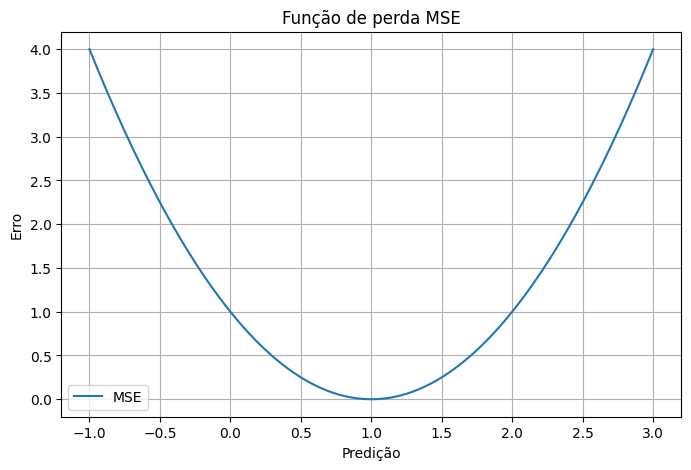

In [34]:
# Exemplo MSE
import torch
import matplotlib.pyplot as plt

y_true = torch.tensor([1.0])

y_pred = torch.linspace(-1, 3, 200)

mse = (y_pred - y_true)**2

plt.figure(figsize=(8,5))
plt.plot(y_pred, mse, label="MSE")

plt.grid(True)
plt.legend()
plt.xlabel("Predição")
plt.ylabel("Erro")
plt.title("Função de perda MSE")

plt.show()

### Classificação binária: Binary Cross Entropy

$$
L = -[y\log(\hat{y}) + (1-y)\log(1-\hat{y})]
$$



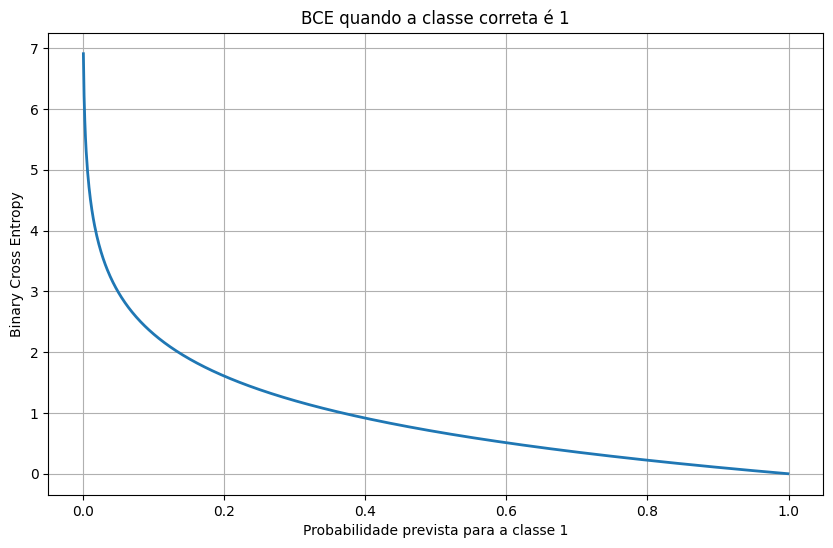

In [35]:
import torch
import matplotlib.pyplot as plt

p = torch.linspace(0.001, 0.999, 1000)

loss = -torch.log(p)

plt.figure(figsize=(10,6))

plt.plot(p, loss, linewidth=2)

plt.grid(True)

plt.xlabel("Probabilidade prevista para a classe 1")
plt.ylabel("Binary Cross Entropy")

plt.title("BCE quando a classe correta é 1")

plt.show()

### Classificação multiclasse: Categorical Cross Entropy

$$
L = -\sum_{i=1}^{K} y_i \log(\hat{y}_i)
$$

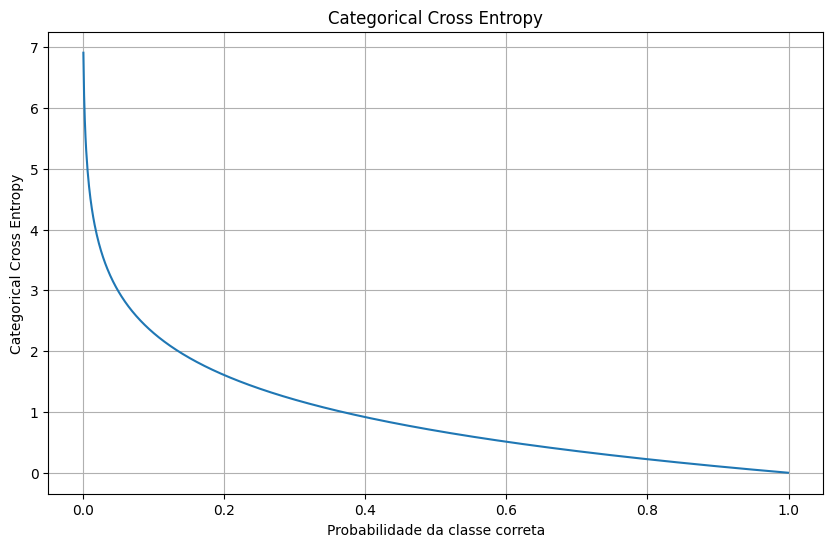

In [36]:
import torch
import matplotlib.pyplot as plt

p = torch.linspace(
    0.001,
    0.999,
    1000
)

loss = -torch.log(p)

plt.figure(figsize=(10,6))

plt.plot(p, loss)

plt.grid(True)

plt.xlabel("Probabilidade da classe correta")
plt.ylabel("Categorical Cross Entropy")

plt.title("Categorical Cross Entropy")

plt.show()

## Gradiente Descendente

O **gradiente descendente** é um algoritmo de otimização utilizado para ajustar os pesos da rede.

A ideia é atualizar os pesos na direção oposta ao gradiente da função de perda.

$$
w = w - \eta \frac{\partial J}{\partial w}
$$

onde:

- $w$ representa um peso da rede;
- $J$ é a função de perda;
- $\eta$ é a taxa de aprendizado;
- $\frac{\partial J}{\partial w}$ é o gradiente da perda em relação ao peso.

## Backpropagation

O **Backpropagation** é o algoritmo utilizado para calcular os gradientes dos pesos em redes neurais.

Ele funciona em duas etapas principais:

1. **Forward propagation:** os dados passam pela rede e a saída é calculada.
2. **Backward propagation:** o erro é propagado de volta pela rede para calcular os gradientes.

O Backpropagation utiliza a **regra da cadeia** do cálculo diferencial.

Fluxo geral:

```text
Entrada → Forward → Saída prevista → Cálculo da perda
                                      ↓
Atualização dos pesos ← Backpropagation
```

## Overfitting e Underfitting

Durante o treinamento, podemos observar três situações principais:

### Underfitting

O modelo é simples demais e não aprende bem nem os dados de treinamento.

### Overfitting

O modelo aprende muito bem os dados de treinamento, mas generaliza mal para novos dados.

### Boa generalização

O modelo apresenta bom desempenho nos dados de treinamento e também nos dados de validação/teste.

## Técnicas de regularização

Algumas técnicas ajudam a reduzir overfitting:

### Dropout

Durante o treinamento, desativa aleatoriamente alguns neurônios.

### Regularização L2

Penaliza pesos muito grandes.

$$
J = Loss + \lambda \sum w^2
$$

### Early Stopping

Interrompe o treinamento quando o erro de validação para de melhorar.

## Principais arquiteturas de Deep Learning

### Redes Feedforward / MLP

Utilizadas em dados tabulares e problemas gerais de classificação/regressão.

### Redes Convolucionais (CNN)

Muito utilizadas em visão computacional, imagens, vídeos e processamento espacial.

### Redes Recorrentes (RNN)

Projetadas para dados sequenciais, como séries temporais e texto.

### LSTM e GRU

Variações de RNN que lidam melhor com dependências de longo prazo.

### Transformers

Arquiteturas modernas baseadas em mecanismos de atenção. São a base de muitos modelos atuais de linguagem, tradução, visão computacional e modelos generativos.

### Redes em Aprendizado por Reforço Profundo

Em Aprendizado por Reforço Profundo, redes neurais são usadas para aproximar funções de valor, políticas ou modelos do ambiente. Exemplos incluem:

- DQN;
- PPO;
- DDPG;
- TD3;
- SAC.

## Exemplo com Pytorch

O Pytorch é uma biblioteca de código fonte aberto utilizada para a implementação de modelos de aprendizado profundo, principalmente nas áreas de processamento de linguagem natural e visão computacional.

Foi desenvolvida pelo Laboratório de IA do Facebook (FAIR) em 2016.

## Exemplo com Pytorch (CLASSIFICAÇÃO) (Dataset IRIS)

O conjunto de dados que compõe o dataset IRIS foi coletado pelo estatístico e biólogo britânico Ronald A. Fisher em 1936, com base em medições realizadas pelo botânico Edgar Anderson. O artigo original, **The Use of Multiple Measurements in Taxonomic Problems**, tornou o Iris um dos datasets mais famosos da literatura.

O objetivo é classificar uma flor em uma das três espécies com base em medidas de suas pétalas e sépalas.

As três classes são:

* Iris setosa
* Iris versicolor
* Iris virginica

Cada espécie possui 50 amostras, totalizando:

* 150 exemplos
* 3 classes balanceadas

Cada flor é descrita por quatro atributos numéricos:

* Comprimento da sépala (cm)
* Largura da sépala (cm)
* Comprimento da pétala	(cm)
* Largura da pétala (cm)

In [37]:
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from torch.utils.data import TensorDataset, DataLoader

In [38]:
# Carregando os dados do dataset
iris = load_iris()

X = iris.data
y = iris.target

In [39]:
# Padronizando os dados
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [40]:
# Separação dos conjuntos de treinamento e de teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [41]:
# Criação dos tensores
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test  = torch.tensor(y_test, dtype=torch.long)

In [42]:
# Separando os dados em mini-batches
train_dataset = TensorDataset(X_train, y_train)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

In [43]:
# Definição da rede neural
class RedeNeural(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(4, 8)
        self.fc2 = nn.Linear(8, 8)
        self.fc3 = nn.Linear(8, 3)

        self.relu = nn.ReLU()

    def forward(self, x):

        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)

        return x

In [44]:
# Instanciando o modelo
modelo = RedeNeural()

In [45]:
# Definindo a função de perda
criterion = nn.CrossEntropyLoss()

In [46]:
# Definindo o otimizador
optimizer = optim.Adam(
    modelo.parameters(),
    lr=0.01
)

In [47]:
# Treinando a rede
num_epochs = 100

for epoch in range(num_epochs):

    for X_batch, y_batch in train_loader:

        # Forward
        outputs = modelo(X_batch)

        loss = criterion(outputs, y_batch)

        # Zera gradientes
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Atualiza pesos
        optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(
            f"Época {epoch+1}/{num_epochs} "
            f"Loss: {loss.item():.4f}"
        )

Época 10/100 Loss: 0.1845
Época 20/100 Loss: 0.0593
Época 30/100 Loss: 0.0877
Época 40/100 Loss: 0.0044
Época 50/100 Loss: 0.0141
Época 60/100 Loss: 0.0006
Época 70/100 Loss: 0.0029
Época 80/100 Loss: 0.0003
Época 90/100 Loss: 0.0033
Época 100/100 Loss: 0.0001


In [48]:
# Avaliação do modelo
with torch.no_grad():

    outputs = modelo(X_test)

    _, predicted = torch.max(outputs, 1)

    accuracy = (predicted == y_test).float().mean()

print(f"Acurácia: {accuracy*100:.2f}%")

Acurácia: 100.00%


In [49]:
# Fazendo predições com a rede

# Comprimento da sépala, largura da sépala, comprimento da pétala e largura da pétala
nova_amostra = [[5.1, 3.5, 1.4, 0.2]]

# Normaliza a entrada da rede
nova_amostra = scaler.transform(
    nova_amostra
)

# Transforma os dados de entrada em tensores
entrada = torch.tensor(
    nova_amostra,
    dtype=torch.float32
)

# Coloca a rede em modo avaliação
modelo.eval()

# Executa sem calcular os gradientes
with torch.no_grad():

    logits = modelo(entrada)

    probs = torch.softmax(
        logits,
        dim=1
    )

    classe = torch.argmax(
        probs,
        dim=1
    )

# Mostra a qual classe pertence a entrada
print("Classe:", classe.item())

# Mostra o nome da flor
print(
    "Flor:",
    iris.target_names[
        classe.item()
    ]
)

# Mostra as probabilidades para cada classe (setosa, versicolor e virginica)
print("Probabilidades:")

for i, nome in enumerate(
    iris.target_names
):
    print(
        f"{nome}: "
        f"{probs[0][i]:.4f}"
    )

Classe: 0
Flor: setosa
Probabilidades:
setosa: 1.0000
versicolor: 0.0000
virginica: 0.0000


## Exemplo com TensorFlow (CLASSIFICAÇÃO) (Dataset IRIS)

In [50]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

In [51]:
# Carregando o dataset Iris
iris = load_iris()
X = iris.data
y = iris.target

In [52]:
# Separação em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [53]:
# Padronização dos dados
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (120, 4)
Teste: (30, 4)


In [54]:
# Gerando o modelo da rede
model = Sequential([
    Dense(16, activation='relu', input_shape=(4,)),
    Dense(8, activation='relu'),
    Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

In [55]:
# Definindo a métrica de validação
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

In [56]:
# Treinando o modelo
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.1979 - loss: 1.5426 - val_accuracy: 0.1667 - val_loss: 1.4713
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1875 - loss: 1.4598 - val_accuracy: 0.1667 - val_loss: 1.4029
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1979 - loss: 1.3823 - val_accuracy: 0.1667 - val_loss: 1.3407
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1979 - loss: 1.3139 - val_accuracy: 0.1667 - val_loss: 1.2852
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2188 - loss: 1.2510 - val_accuracy: 0.2500 - val_loss: 1.2353
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.2500 - loss: 1.1933 - val_accuracy: 0.2500 - val_loss: 1.1917
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3125 - loss: 1.1415 - val_accuracy: 0.2083 - val_loss: 1.1521
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3438 - loss: 1.0972 - val_accuracy: 0.2500 - val_loss:

In [57]:
# Avaliação do modelo
loss, acc = model.evaluate(X_test, y_test, verbose=0)

print("Loss no teste:", loss)
print("Acurácia no teste:", acc)

Loss no teste: 0.0819196030497551
Acurácia no teste: 0.9666666388511658


In [58]:
# Fazendo predições
nova_amostra = [[5.1, 3.5, 1.4, 0.2]]

nova_amostra = scaler.transform(
    nova_amostra
)

probabilidades = model.predict(
    nova_amostra
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


In [59]:
import numpy as np

classe = np.argmax(
    probabilidades,
    axis=1
)

In [60]:
print(
    iris.target_names[
        classe[0]
    ]
)

setosa


# Referências

* Mãos à Obra: aprendizado de máquina com scikit-learn, keras & tensorflow.

* Inteligência Artificial - uma abordagem de aprendizado de máquina.

# Créditos

* As imagens foram geradas pelo chatgpt.